# Honeytokens en Bases de Datos Relacionales

**Flujo del notebook:**
1. Instalación y conexión a la BD
2. Preparación de la base de datos (tablas + seed_data)
3. Carga de datos reales
4. Definición de metadata relacional
5. *(Una sola vez)* Generación e inserción de honeytokens con HMA
6. Carga de honeytokens existentes desde la BD *(alternativa a la sección 5)*
7. Evaluación de calidad estadística (SDV)
8. Evaluación detallada (table-evaluator)
9. Simulación de ataque y detección (capa de aplicación)
10. Análisis de rendimiento (EXPLAIN ANALYZE)
11. Mecanismo nativo de detección en PostgreSQL (trigger + pg_notify, pgAudit)

Cada sección numerada instrumenta la sección homónima del Capítulo 5 (Marco Metodológico) y sustenta los resultados reportados en el Capítulo 6 de la tesina, sobre el dataset hospitalario (hospitals, doctors, patients, admissions).

## 1. Instalación de dependencias

Se instalan `sdv` (síntesis jerárquica de honeytokens), `table-evaluator` (validación estadística complementaria), `pandas`, `sqlalchemy` y `psycopg2-binary` (conexión a PostgreSQL): las herramientas seleccionadas en la Sección 5.5 de la tesina.

In [1]:
import sys
print(f"Python: {sys.version}")
print(f"Ejecutable: {sys.executable}")

!{sys.executable} -m pip install sdv pandas sqlalchemy psycopg2-binary table-evaluator -q

import torch

print("listo")


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Ejecutable: C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Scripts\python.exe


listo


## 2. Conexión a la Base de Datos (PostgreSQL)

Se arma la cadena de conexión con SQLAlchemy. El bloque activo apunta a la instancia local de PostgreSQL 17 en Docker descripta en la Sección 5.10 de la tesina.

In [2]:
from sqlalchemy import create_engine, text

# --- PostgreSQL local  ---
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_NAME = "postgres"
DB_USER = "postgres"

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:5432/{DB_NAME}"

engine = create_engine(DATABASE_URL, connect_args={'connect_timeout': 10}, pool_pre_ping=True)

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))

print("conexión ok")


conexión ok


## 3. Preparación de la Base de Datos *(ejecutar una sola vez)*

Ejecuta `schema.sql` (crea las cuatro tablas del esquema si todavía no existen) y `seed_data.sql` (carga los 7.921 registros reales del dataset hospitalario de la Sección 5.10 de la tesina). Si la base ya tiene los datos cargados, la celda lo detecta y no vuelve a insertarlos.

In [3]:
from sqlalchemy import text

with open('schema.sql', encoding='utf-8') as f:
    schema_sql = f.read()

with engine.begin() as conn:
    conn.execute(text(schema_sql))
    n_pacientes = conn.execute(text('SELECT count(*) FROM patients')).scalar()

print('tablas creadas (o ya existentes): hospitals, doctors, patients, admissions')

if n_pacientes > 0:
    print(f'patients ya tiene {n_pacientes} filas — no se vuelve a cargar seed_data.sql')
else:
    with open('seed_data.sql', encoding='utf-8') as f:
        seed_sql = f.read()
    with engine.begin() as conn:
        conn.execute(text(seed_sql))
    print('seed_data.sql cargado: 1950 hospitals, 1971 doctors, 2000 patients, 2000 admissions')


tablas creadas (o ya existentes): hospitals, doctors, patients, admissions
patients ya tiene 2100 filas — no se vuelve a cargar seed_data.sql


## 4. Carga de Datos Reales

Se cargan todos los registros y se clasifican en Python usando la fórmula SHA-256 con sal secreta. De esta forma todos los registros tienen `hash_id`.

In [4]:
import pandas as pd
import hashlib
from sqlalchemy import text

PKS = {
    'hospitals': 'hospital_id',
    'doctors': 'doctor_id',
    'patients': 'patient_id',
    'admissions': 'admission_id',
}

SECRET_SALT = "UADER_Sistemas_2026_SecureSalt_Tokenization"

def fetch_table(engine, table_name, where_clause=""):
    all_data = []
    offset = 0
    limit = 1000
    with engine.connect() as conn:
        while True:
            q = text(f'SELECT * FROM "{table_name}" {where_clause} ORDER BY 1 LIMIT :limit OFFSET :offset')
            rows = conn.execute(q, {'limit': limit, 'offset': offset}).fetchall()
            data = [dict(r._mapping) for r in rows]
            if not data:
                break
            all_data.extend(data)
            offset += limit
    df = pd.DataFrame(all_data)
    for col in df.columns:
        if 'date' in col.lower():
            try:
                df[col] = pd.to_datetime(df[col])
            except (ValueError, TypeError):
                pass
    return df

def generar_hash_honeytoken(pk_val, salt=SECRET_SALT):
    return hashlib.sha256(f"{pk_val}{salt}".encode('utf-8')).hexdigest()

def es_honeytoken(pk_val, hash_val):
    return generar_hash_honeytoken(pk_val) == hash_val


# cargar todo y filtrar por fórmula criptográfica
datos_reales = {}
for table_name, pk_col in PKS.items():
    df_all = fetch_table(engine, table_name)
    if df_all.empty:
        datos_reales[table_name] = df_all
        continue
    mask_honey = df_all.apply(lambda r: es_honeytoken(r[pk_col], r.get('hash_id')), axis=1)
    datos_reales[table_name] = df_all[~mask_honey].copy()
    print(f"{table_name}: {(~mask_honey).sum()} reales, {mask_honey.sum()} honeytokens excluidos")


hospitals: 1950 reales, 98 honeytokens excluidos
doctors: 1971 reales, 99 honeytokens excluidos
patients: 2000 reales, 100 honeytokens excluidos
admissions: 2000 reales, 100 honeytokens excluidos


## 5. Definición de Metadata Relacional

Se construye el objeto `MultiTableMetadata` de SDV: se detectan los tipos de datos automáticamente y se declaran las claves primarias y las relaciones padre-hijo (hospitals, doctors, patients → admissions) descriptas en la Sección 5.10.A, necesarias para que el HMA aprenda la integridad referencial.

In [5]:
from sdv.metadata import MultiTableMetadata

metadata = MultiTableMetadata()
metadata.detect_from_dataframes(data=datos_reales)

metadata.set_primary_key(table_name='hospitals', column_name='hospital_id')
metadata.set_primary_key(table_name='doctors', column_name='doctor_id')
metadata.set_primary_key(table_name='patients', column_name='patient_id')
metadata.set_primary_key(table_name='admissions', column_name='admission_id')

metadata.relationships = []
metadata.add_relationship(
    parent_table_name='hospitals', child_table_name='admissions',
    parent_primary_key='hospital_id', child_foreign_key='hospital_id'
)
metadata.add_relationship(
    parent_table_name='doctors', child_table_name='admissions',
    parent_primary_key='doctor_id', child_foreign_key='doctor_id'
)
metadata.add_relationship(
    parent_table_name='patients', child_table_name='admissions',
    parent_primary_key='patient_id', child_foreign_key='patient_id'
)

# metadata.visualize()


C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\metadata\single_table.py:937: UserWarning: There is an existing primary key 'hospital_id'. This key will be removed.
  warnings.warn(
C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\metadata\single_table.py:937: UserWarning: There is an existing primary key 'doctor_id'. This key will be removed.
  warnings.warn(
C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\metadata\single_table.py:937: UserWarning: There is an existing primary key 'patient_id'. This key will be removed.
  warnings.warn(
C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\metadata\single_table.py:937: UserWarning: There is an existing primary key 'admission_id'. This key will be removed.
  warnings.warn(


## 6. Generación e Inserción de Honeytokens

Implementa la Sección 5.10.B y 5.10.C de la tesina: entrenamiento del HMA Synthesizer, generación de los señuelos con `scale=0.05` y su cifrado e inserción jerárquica en la base de datos.

Si los honeytokens ya están en la BD, saltar esta sección y ejecutar directamente la Sección 7.

### 6a. Entrenar HMA y generar honeytokens

Se entrena el `HMASynthesizer` sobre los datos reales y se generan los honeytokens con `scale=0.05` (Sección 5.10.B), registrando el tiempo de entrenamiento y la similitud estadística global (`evaluate_quality`).

In [32]:
from sdv.multi_table import HMASynthesizer
from sdv.evaluation.multi_table import evaluate_quality
import time

t_inicio = time.time()
print("Entrenando HMASynthesizer...")
synthesizer = HMASynthesizer(metadata)
synthesizer.fit(datos_reales)
t_entrenamiento = time.time() - t_inicio
print(f"listo — tiempo de entrenamiento: {t_entrenamiento:.1f}s\n")

honeytokens_generados = synthesizer.sample(scale=0.05)

for tabla, df in honeytokens_generados.items():
    print(f"  {tabla}: {len(df)} honeytokens generados")

quality_report = evaluate_quality(
    real_data=datos_reales,
    synthetic_data=honeytokens_generados,
    metadata=metadata,
    verbose=False
)
print(f"\nsimilitud estadística: {quality_report.get_score() * 100:.2f}%")
print(f"overhead de síntesis (off-line): {t_entrenamiento:.1f}s")


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_16008\699798324.py:2: FutureWarning: The evaluation functions are now accessible via the 'sdv.evaluation' module.
  from sdv.evaluation.multi_table import evaluate_quality
c:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\multi_table\base.py:143: FutureWarning: The 'MultiTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\multi_table\base.py:117: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
c:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


Entrenando HMASynthesizer...


Preprocess Tables: 100%|██████████| 4/4 [00:06<00:00,  1.57s/it]



Learning relationships:


(1/3) Tables 'hospitals' and 'admissions' ('hospital_id'): 100%|██████████| 1950/1950 [00:20<00:00, 92.97it/s] 
(2/3) Tables 'doctors' and 'admissions' ('doctor_id'): 100%|██████████| 1971/1971 [00:20<00:00, 95.15it/s] 
(3/3) Tables 'patients' and 'admissions' ('patient_id'): 100%|██████████| 2000/2000 [00:21<00:00, 91.32it/s] 


Modeling Tables: 100%|██████████| 4/4 [00:02<00:00,  1.35it/s]


listo — tiempo de entrenamiento: 78.4s

  doctors: 99 honeytokens generados
  admissions: 100 honeytokens generados
  patients: 100 honeytokens generados
  hospitals: 98 honeytokens generados

similitud estadística: 44.44%
overhead de síntesis (off-line): 78.4s


### 6b. Cifrar con hash e insertar en la base de datos

Cada honeytoken recibe su `hash_id` (SHA-256 con sal, Sección 5.12) y se inserta respetando el orden jerárquico padres→hijo (`hospitals → doctors → patients → admissions`) para no violar las restricciones de clave foránea.

In [33]:
import hashlib
from sqlalchemy import text

SECRET_SALT = "UADER_Sistemas_2026_SecureSalt_Tokenization"

def generar_hash_honeytoken(id_valor, salt=SECRET_SALT):
    return hashlib.sha256(f"{id_valor}{salt}".encode('utf-8')).hexdigest()


for tabla in list(honeytokens_generados.keys()):
    pk = PKS[tabla]
    honeytokens_generados[tabla] = honeytokens_generados[tabla].assign(
        hash_id=honeytokens_generados[tabla][pk].apply(generar_hash_honeytoken)
    )
    assert honeytokens_generados[tabla]['hash_id'].notna().all(), f"hash_id nulo en {tabla}"

print("hash_id asignado\n")

orden_insercion = ['hospitals', 'doctors', 'patients', 'admissions']

try:
    with engine.connect() as conn:
        for table_name in orden_insercion:
            df_temp = honeytokens_generados[table_name].copy()
            pk_col = PKS[table_name]

            if 'hash_id' not in df_temp.columns or df_temp['hash_id'].isna().any():
                raise ValueError(f"hash_id faltante en {table_name}")

            for col in df_temp.select_dtypes(include=['datetime64', 'datetime']).columns:
                df_temp[col] = df_temp[col].dt.strftime('%Y-%m-%d %H:%M:%S')

            records = df_temp.to_dict('records')
            if not records:
                continue

            cols = df_temp.columns.tolist()
            # los nombres de columnas con espacios no son válidos como bind params de SQLAlchemy
            param_names = [c.replace(' ', '_') for c in cols]

            insert_cols = ', '.join(f'"{c}"' for c in cols)
            placeholders = ', '.join(f':{p}' for p in param_names)
            update_cols = ', '.join(
                f'"{c}" = EXCLUDED."{c}"' for c, p in zip(cols, param_names) if c != pk_col
            )

            if update_cols:
                sql = text(f"""
                    INSERT INTO "{table_name}" ({insert_cols})
                    VALUES ({placeholders})
                    ON CONFLICT ("{pk_col}") DO UPDATE SET {update_cols}
                """)
            else:
                sql = text(f"""
                    INSERT INTO "{table_name}" ({insert_cols})
                    VALUES ({placeholders})
                    ON CONFLICT ("{pk_col}") DO NOTHING
                """)

            records_remapped = [
                {p: rec[c] for c, p in zip(cols, param_names)}
                for rec in records
            ]

            for rec in records_remapped:
                conn.execute(sql, rec)
            conn.commit()
            print(f"  {table_name}: {len(records)} insertados")

    print("\nhoneytokens insertados en la Base de Datos")
except Exception as e:
    print(f"Error: {e}")


hash_id asignado

  hospitals: 98 insertados
  doctors: 99 insertados
  patients: 100 insertados
  admissions: 100 insertados

honeytokens insertados en la Base de Datos


## 7. Carga de Honeytokens desde la Base de Datos

Alternativa a la Sección 6: si los honeytokens ya existen en la BD, usar esta celda para cargarlos directamente.

### 7c. Asignar hash_id a registros reales *(ejecutar una sola vez)*

Los registros reales reciben `SHA-256(PK)` sin sal secreta, y los honeytokens tienen `SHA-256(PK + SECRET_SALT)`. Así todos los registros tienen `hash_id` y el atacante no puede identificar señuelos por ausencia de hash.

In [6]:
import hashlib
from sqlalchemy import text

def hash_registro_real(pk_val):
    return hashlib.sha256(str(pk_val).encode('utf-8')).hexdigest()

with engine.connect() as conn:
    for table_name, pk_col in PKS.items():
        rows = conn.execute(
            text(f'SELECT "{pk_col}" FROM "{table_name}" WHERE "hash_id" IS NULL')
        ).fetchall()
        if not rows:
            print(f"{table_name}: ya tiene hash_id")
            continue
        for row in rows:
            pk_val = dict(row._mapping)[pk_col]
            conn.execute(
                text(f'UPDATE "{table_name}" SET "hash_id" = :h WHERE "{pk_col}" = :pk AND "hash_id" IS NULL'),
                {'h': hash_registro_real(pk_val), 'pk': pk_val}
            )
        conn.commit()
        print(f"{table_name}: {len(rows)} registros actualizados")


hospitals: ya tiene hash_id
doctors: ya tiene hash_id
patients: ya tiene hash_id
admissions: ya tiene hash_id


In [7]:
import hashlib

SECRET_SALT = "UADER_Sistemas_2026_SecureSalt_Tokenization"

def generar_hash_honeytoken(pk_val, salt=SECRET_SALT):
    return hashlib.sha256(f"{pk_val}{salt}".encode('utf-8')).hexdigest()

def es_honeytoken(pk_val, hash_val):
    return generar_hash_honeytoken(pk_val) == hash_val


honeytokens_generados = {}
for table_name, pk_col in PKS.items():
    df_all = fetch_table(engine, table_name)
    if df_all.empty:
        continue
    mask_honey = df_all.apply(lambda r: es_honeytoken(r[pk_col], r.get('hash_id')), axis=1)
    df_honey = df_all[mask_honey].copy()
    if not df_honey.empty:
        honeytokens_generados[table_name] = df_honey
        print(f"{table_name}: {len(df_honey)} honeytokens")
    else:
        print(f"{table_name}: sin honeytokens en BD")

if 'patients' in honeytokens_generados:
    display(honeytokens_generados['patients'].head())


hospitals: 98 honeytokens
doctors: 99 honeytokens
patients: 100 honeytokens


admissions: 100 honeytokens


,patient_id,Name,Age,Gender,Blood Type,Insurance Provider,hash_id
2000,78341,mARilYN TRAn,35,Female,O+,Cigna,c7894c03264862878819b2bec155fdfea90dcccdefd112...
2001,169333,JESsiCA wooD,67,Female,B+,UnitedHealthcare,d44967f7bf8a7a0f198e411e98df2ff85a52156efb7d8a...
2002,222037,tiNA PriCE,70,Female,A+,UnitedHealthcare,f9c75cb2d13df622c539e459f4a202055a9fd93c927375...
2003,232590,NIColE mArTIN,21,Male,A+,Blue Cross,eca903aa78eb7953c948dbe1c42373153004b34d7e667a...
2004,235975,JOHn mCcArTY,57,Male,A-,Medicare,d0fae61c3a87889b12a1920a598c83458fcd04c16c3b3e...


## 8. Validación de la Generación de Honeytokens

**8a** Reporte diagnóstico: validez estructural (Data Validity, Data Structure, Relationship Validity).

**8b** Reporte de calidad: similitud estadística por columnas, pares de columnas y relaciones entre tablas.

In [8]:
from sdv.evaluation.multi_table import run_diagnostic

# 8a Reporte diagnóstico: valida que la estructura relacional fue respetada
diag = run_diagnostic(
    real_data=datos_reales,
    synthetic_data=honeytokens_generados,
    metadata=metadata,
)
display(diag.get_properties())


C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdmetrics\reports\multi_table\__init__.py:17: FutureWarning: The multi table diagnostic report is deprecated. Please use the DiagnosticReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.multi_table.diagnostic_report import DiagnosticReport
C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sdmetrics\reports\multi_table\__init__.py:12: FutureWarning: The multi table quality report is deprecated. Please use the QualityReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.multi_table.quality_report import QualityReport
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2688\1869616559.py:1: FutureWarning: The evaluation functions are now accessible via the 'sdv.evaluation' module.
  from sdv.evaluation.multi_table import run_diagnostic


Generating report ...




|          | 0/26 [00:00<?, ?it/s]|


(1/3) Evaluating Data Validity: |          | 0/26 [00:00<?, ?it/s]|


(1/3) Evaluating Data Validity: |█████████▌| 25/26 [00:00<00:00, 447.10it/s]|

...


(3/3) Evaluating Relationship Validity: |          | 0/3 [00:00<?, ?it/s]|


(3/3) Evaluating Relationship Validity: |██████████| 3/3 [00:00<00:00, 62.83it/s]|


Relationship Validity Score: 100.0%



Overall Score (Average): 100.0%



,Property,Score
0,Data Validity,1.0
1,Data Structure,1.0
2,Relationship Validity,1.0


In [9]:
from sdv.evaluation.multi_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=datos_reales,
    synthetic_data=honeytokens_generados,
    metadata=metadata,
)

print(f"\npuntuación de similitud: {quality_report.get_score() * 100:.2f}%\n")
display(quality_report.get_properties())


Generating report ...



C:\Users\Gabriel\AppData\Local\Temp\ipykernel_2688\640679213.py:1: FutureWarning: The evaluation functions are now accessible via the 'sdv.evaluation' module.
  from sdv.evaluation.multi_table import evaluate_quality



|          | 0/26 [00:00<?, ?it/s]|


(1/4) Evaluating Column Shapes: |          | 0/26 [00:00<?, ?it/s]|


(1/4) Evaluating Column Shapes: |███▊      | 10/26 [00:00<00:00, 99.89it/s]|

...


(4/4) Evaluating Intertable Trends: |████████▏ | 138/169 [00:00<00:00, 157.67it/s]|


(4/4) Evaluating Intertable Trends: |██████████| 169/169 [00:00<00:00, 170.76it/s]|


Intertable Trends Score: 0.87%



Overall Score (Average): 44.44%


puntuación de similitud: 44.44%



,Property,Score
0,Column Shapes,0.685329
1,Column Pair Trends,0.085376
2,Cardinality,0.998113
3,Intertable Trends,0.008661


## 9. Análisis Estadístico Detallado y Análisis Multivariado

**9a** Evaluación columna a columna con table-evaluator: distribuciones, correlaciones y clasificador.

**9b** Reducción de dimensionalidad (PCA) y matrices de correlación para validar indistinguibilidad multivariada.

In [10]:
from table_evaluator import TableEvaluator

columnas_analisis = [
    'Medical Condition', 'Admission Type', 'Room Number',
    'Medication', 'Test Results', 'Billing Amount'
]

n_honey = len(honeytokens_generados['admissions'])
muestra_real = datos_reales['admissions'][columnas_analisis].sample(n=n_honey, random_state=42)
muestra_honey = honeytokens_generados['admissions'][columnas_analisis]

print(f"Comparando {n_honey} honeytokens vs {n_honey} registros reales (admissions)\n")

evaluador = TableEvaluator(muestra_real, muestra_honey)
evaluador.evaluate(target_col='Test Results', kfold=False)


IPython not installed.


Comparando 100 honeytokens vs 100 registros reales (admissions)



C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Adding missing column Billing Amount_89 with all 0s to fake dataset


...

C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\table_evaluator\data\data_converter.py:364: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake_encoded[col] = 0.0
Adding missing column Billing Amount_98 with all 0s to fake dataset


C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\table_evaluator\data\data_converter.py:364: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake_encoded[col] = 0.0
Adding missing column Billing Amount_99 with all 0s to fake dataset



Classifier F1-scores and their Jaccard similarities::
    real   fake
0 0.6576 0.6576

Privacy results:
                                         result
Duplicate rows between sets (real/fake)  (0, 0)
nearest neighbor mean                    1.9634
nearest neighbor std                     0.2648

Miscellaneous results:
                                  Result
Column Correlation Distance RMSE  0.0599
Column Correlation distance MAE   0.0421

Results:
                                                result
Basic statistics                                1.0000
Correlation column correlations                 0.9869
Mean Correlation between fake and real columns  0.3547
1 - MAPE Estimator results                      0.6576
Similarity Score                                0.7498


C:\Users\Gabriel\Documents\Facultad\Tesina\.venv\Lib\site-packages\table_evaluator\data\data_converter.py:364: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake_encoded[col] = 0.0


{'Basic statistics': 1.0,
 'Correlation column correlations': 0.9869492714121373,
 'Mean Correlation between fake and real columns': 0.35470183865427013,
 '1 - MAPE Estimator results': 0.6576388888888889,
 'Similarity Score': 0.7498224997388241}

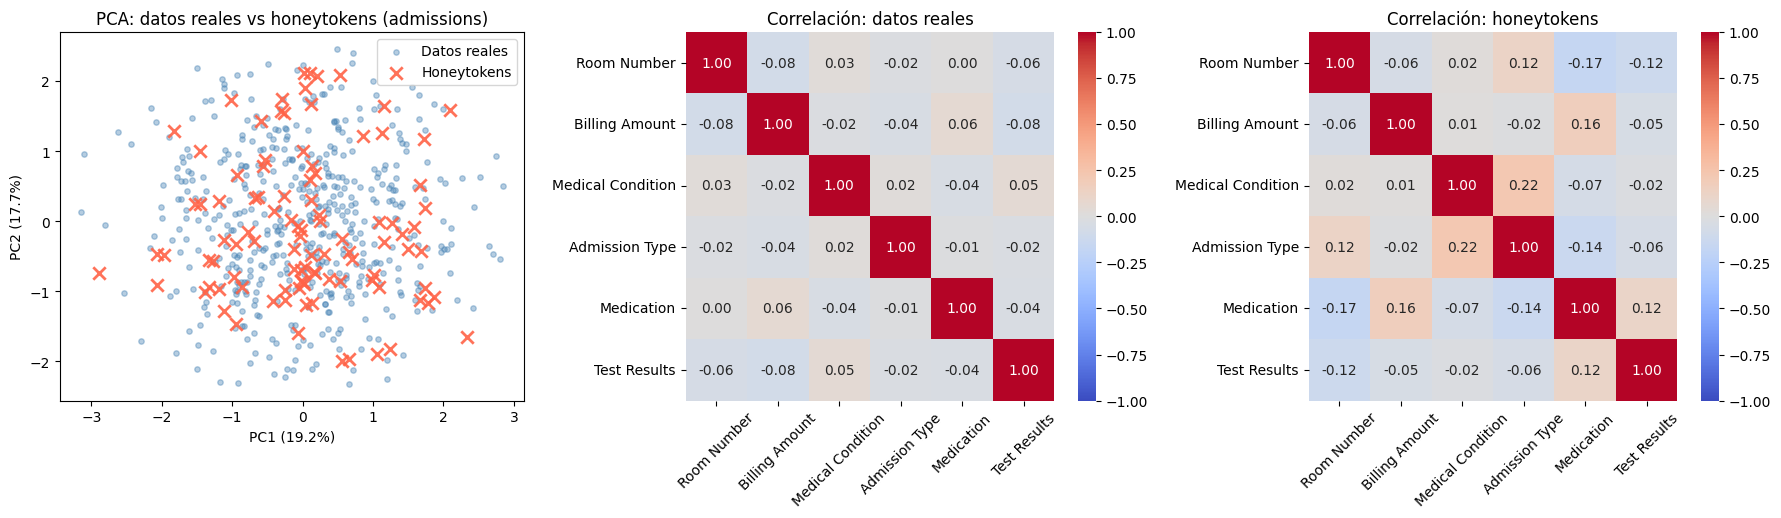

varianza explicada PC1+PC2: 36.9%
diferencia media entre matrices de correlación: 0.0678


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

cols_num = ['Room Number', 'Billing Amount']
cols_cat = ['Medical Condition', 'Admission Type', 'Medication', 'Test Results']

def encode_para_pca(df):
    df_enc = df[cols_num + cols_cat].copy()
    for col in cols_cat:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc.fillna(0).astype(float)

n = min(500, len(datos_reales['admissions']))
real_enc  = encode_para_pca(datos_reales['admissions'].sample(n=n, random_state=42))
honey_enc = encode_para_pca(honeytokens_generados['admissions'])

scaler = StandardScaler()
X_real_sc  = scaler.fit_transform(real_enc)
X_honey_sc = scaler.transform(honey_enc)

pca = PCA(n_components=2)
real_pca  = pca.fit_transform(X_real_sc)
honey_pca = pca.transform(X_honey_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA scatter
axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.4, s=15, label='Datos reales', c='steelblue')
axes[0].scatter(honey_pca[:, 0], honey_pca[:, 1], alpha=0.9, s=80, label='Honeytokens', c='tomato', marker='x', linewidths=2)
axes[0].set_title('PCA: datos reales vs honeytokens (admissions)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Heatmaps de correlación
corr_real  = real_enc.corr()
corr_honey = honey_enc.corr()

sns.heatmap(corr_real, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1, square=True)
axes[1].set_title('Correlación: datos reales')
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(corr_honey, ax=axes[2], cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1, square=True)
axes[2].set_title('Correlación: honeytokens')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

var_explicada = sum(pca.explained_variance_ratio_) * 100
dif_corr = (corr_real - corr_honey).abs().mean().mean()
print(f"varianza explicada PC1+PC2: {var_explicada:.1f}%")
print(f"diferencia media entre matrices de correlación: {dif_corr:.4f}")


## 10. Simulación de Ataque, Detección y Matriz de Confusión

Se simula un atacante que accede a un registro honeytoken en la tabla de pacientes. El sistema detecta el acceso por SHA-256 y se evalúa la precisión del mecanismo mediante métricas de clasificación binaria (TP, TN, FP, FN).

In [12]:
import time
from sqlalchemy import text

honey_patients = honeytokens_generados['patients']
honey_hashes_set = set(honey_patients['hash_id'].values)

id_trampa = int(honey_patients['patient_id'].iloc[0])
print(f"simulando acceso al honeytoken patient_id={id_trampa}\n")

t0 = time.time()
with engine.connect() as conn:
    result = conn.execute(
        text('SELECT * FROM patients WHERE patient_id = :id'),
        {'id': id_trampa}
    ).fetchall()
tiempo_exfiltracion = time.time() - t0

t1 = time.time()
es_honeytoken_accedido = False
if result:
    id_accedido = dict(result[0]._mapping)['patient_id']
    hash_acceso = generar_hash_honeytoken(id_accedido)
    es_honeytoken_accedido = hash_acceso in honey_hashes_set
tiempo_deteccion = time.time() - t1

if es_honeytoken_accedido:
    print("ALERTA: honeytoken accedido")
else:
    print("acceso legítimo")
print(f"  exfiltración: {tiempo_exfiltracion:.4f}s | detección: {tiempo_deteccion:.6f}s")

# tráfico mixto: 100 accesos legítimos + 1 al señuelo
trafico_real = datos_reales['patients']['patient_id'].sample(100, random_state=42).tolist()
trafico_mixto = trafico_real + [id_trampa]

TP = TN = FP = FN = 0

for req_id in trafico_mixto:
    hash_req = generar_hash_honeytoken(req_id)
    detectado = hash_req in honey_hashes_set
    es_real_honey = req_id == id_trampa

    if es_real_honey and detectado:
        TP += 1
    elif es_real_honey and not detectado:
        FN += 1
    elif not es_real_honey and detectado:
        FP += 1
    else:
        TN += 1

print(f"\nresultados sobre {len(trafico_mixto)} accesos:")
print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")


simulando acceso al honeytoken patient_id=78341

ALERTA: honeytoken accedido
  exfiltración: 0.0043s | detección: 0.000000s

resultados sobre 101 accesos:
  TP=1  TN=100  FP=0  FN=0


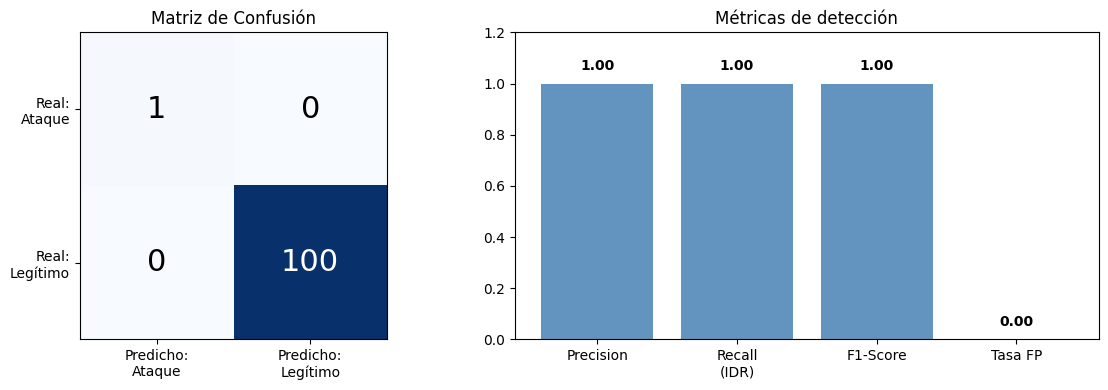

In [13]:
import matplotlib.pyplot as plt
import numpy as np

precision = TP / (TP + FP) if (TP + FP) > 0 else 1.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 1.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
fpr       = FP / (FP + TN) if (FP + TN) > 0 else 0.0

cm = np.array([[TP, FN], [FP, TN]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicho:\nAtaque', 'Predicho:\nLegítimo'])
axes[0].set_yticklabels(['Real:\nAtaque', 'Real:\nLegítimo'])
axes[0].set_title('Matriz de Confusión')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=22,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

# Métricas de clasificación
metricas = ['Precision', 'Recall\n(IDR)', 'F1-Score', 'Tasa FP']
valores  = [precision, recall, f1, fpr]
colores  = ['steelblue', 'steelblue', 'steelblue', 'tomato' if fpr > 0 else 'steelblue']
bars = axes[1].bar(metricas, valores, color=colores, alpha=0.85)
axes[1].set_ylim(0, 1.2)
axes[1].set_title('Métricas de detección')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 11. Análisis de Rendimiento e Impacto en Almacenamiento

**11a** EXPLAIN ANALYZE: verifica que la presencia de honeytokens en las tablas no impacta el tiempo de ejecución de las consultas.

**11b** Overhead de almacenamiento: porcentaje de señuelos insertados respecto al total de registros por tabla.

In [14]:
from sqlalchemy import text

query = text("""
    EXPLAIN ANALYZE
    SELECT * FROM public.patients
    WHERE "Age" > 50
    LIMIT 500;
""")

with engine.connect() as conn:
    resultado = conn.execute(query).fetchall()

for row in resultado:
    linea = row[0]
    if any(k in linea for k in ["Execution Time", "Planning Time", "Scan"]):
        print(linea)


  ->  Seq Scan on patients  (cost=0.00..134.25 rows=1076 width=104) (actual time=0.010..0.127 rows=500 loops=1)
Planning Time: 0.059 ms
Execution Time: 0.266 ms


In [15]:
print("Overhead de almacenamiento por tabla\n")

total_real  = sum(len(df) for df in datos_reales.values())
total_honey = sum(len(df) for df in honeytokens_generados.values())
total = total_real + total_honey

for table_name in PKS:
    n_real  = len(datos_reales[table_name])
    n_honey = len(honeytokens_generados.get(table_name, []))
    pct = n_honey / (n_real + n_honey) * 100 if (n_real + n_honey) > 0 else 0
    print(f"  {table_name:12s}: {n_real:4d} reales + {n_honey:3d} honeytokens ({pct:.2f}%)")

pct_total = total_honey / total * 100
print(f"\n  total: {total_real} reales + {total_honey} honeytokens ({pct_total:.2f}% de señuelos)")
print(f"  factor de escala utilizado: {total_honey/total_real*100:.2f}% del dataset original")


Overhead de almacenamiento por tabla

  hospitals   : 1950 reales +  98 honeytokens (4.79%)
  doctors     : 1971 reales +  99 honeytokens (4.78%)
  patients    : 2000 reales + 100 honeytokens (4.76%)
  admissions  : 2000 reales + 100 honeytokens (4.76%)

  total: 7921 reales + 397 honeytokens (4.77% de señuelos)
  factor de escala utilizado: 5.01% del dataset original


## 12. Mecanismo Nativo de Detección en PostgreSQL (Trigger + pg_notify, pgAudit)

A diferencia de la Sección 10, que verifica el `hash_id` en la capa de aplicación (Python) inmediatamente después de recibir el resultado de la consulta, esta sección implementa la detección directamente en el motor PostgreSQL, sin depender de que el atacante pase por esta notebook. El trigger de autoprotección (12a) reutiliza el `hash_id` salteado (`SECRET_SALT`) definido en la Sección 4; el procedimiento de correlación con pgAudit (12c) coteja directamente contra el id del honeytoken, sin recomputar ese hash, apoyándose en cambio en el control de acceso estricto sobre `honeytoken_registry` (Sección 5.12).

### 12a. Trigger `AFTER INSERT OR UPDATE OR DELETE` + `pg_notify()`

Implementa `fn_alerta_honeytoken()` y el trigger de la Sección 5.7: ante cualquier escritura sobre una fila señuelo, registra la evidencia en `honeytoken_alertas` y emite `pg_notify()` de forma asíncrona. `honeytoken_registry` incorpora además la columna `id_honeytoken` (Sección 5.12), y tanto la tabla como la función quedan bajo el rol dedicado `honeytoken_admin` (`SECURITY DEFINER` + `REVOKE ALL ... FROM PUBLIC`): ningún rol de aplicación puede leer el registro directamente.

In [16]:
from sqlalchemy import text

ddl_trigger = """
CREATE TABLE IF NOT EXISTS honeytoken_registry (
    tabla          text NOT NULL,
    hash_id        text NOT NULL,
    id_honeytoken  bigint NOT NULL,
    PRIMARY KEY (tabla, hash_id)
);
CREATE INDEX IF NOT EXISTS ix_honeytoken_registry_id ON honeytoken_registry (tabla, id_honeytoken);

CREATE TABLE IF NOT EXISTS honeytoken_alertas (
    id            bigserial PRIMARY KEY,
    tabla         text NOT NULL,
    operacion     text NOT NULL,
    hash_id       text NOT NULL,
    usuario_db    text NOT NULL DEFAULT session_user,
    detectado_en  timestamptz NOT NULL DEFAULT clock_timestamp(),
    detalle       jsonb
);

CREATE OR REPLACE FUNCTION fn_alerta_honeytoken() RETURNS trigger
LANGUAGE plpgsql
SECURITY DEFINER
SET search_path = public, pg_temp
AS $$
DECLARE
    v_hash text := COALESCE(NEW.hash_id, OLD.hash_id);
    v_es_honeytoken boolean;
BEGIN
    SELECT EXISTS (
        SELECT 1 FROM honeytoken_registry
        WHERE tabla = TG_TABLE_NAME AND hash_id = v_hash
    ) INTO v_es_honeytoken;

    IF v_es_honeytoken THEN
        INSERT INTO honeytoken_alertas (tabla, operacion, hash_id, detalle)
        VALUES (TG_TABLE_NAME, TG_OP, v_hash,
                jsonb_build_object('backend_pid', pg_backend_pid()));

        PERFORM pg_notify('honeytoken_alert', jsonb_build_object(
            'tabla', TG_TABLE_NAME,
            'operacion', TG_OP,
            'hash_id', v_hash,
            'usuario', session_user,
            'timestamp', clock_timestamp()
        )::text);
    END IF;

    RETURN COALESCE(NEW, OLD);
END;
$$;

DO $$
BEGIN
    IF NOT EXISTS (SELECT 1 FROM pg_roles WHERE rolname = 'honeytoken_admin') THEN
        CREATE ROLE honeytoken_admin NOLOGIN;
    END IF;
END
$$;

GRANT USAGE ON SCHEMA public TO honeytoken_admin;
GRANT pg_read_server_files TO honeytoken_admin;
GRANT SELECT, INSERT ON honeytoken_alertas TO honeytoken_admin;
GRANT USAGE ON SEQUENCE honeytoken_alertas_id_seq TO honeytoken_admin;

ALTER TABLE honeytoken_registry OWNER TO honeytoken_admin;
REVOKE ALL ON honeytoken_registry FROM PUBLIC;

ALTER FUNCTION fn_alerta_honeytoken() OWNER TO honeytoken_admin;
REVOKE ALL ON FUNCTION fn_alerta_honeytoken() FROM PUBLIC;
"""

with engine.begin() as conn:
    conn.execute(text(ddl_trigger))
    for tabla in honeytokens_generados.keys():
        conn.execute(text(f'DROP TRIGGER IF EXISTS trg_honeytoken_{tabla} ON "{tabla}";'))
        conn.execute(text(f'''
            CREATE TRIGGER trg_honeytoken_{tabla}
            AFTER INSERT OR UPDATE OR DELETE ON "{tabla}"
            FOR EACH ROW EXECUTE FUNCTION fn_alerta_honeytoken();
        '''))
    for tabla, df in honeytokens_generados.items():
        pk = PKS[tabla]
        for _, fila in df.iterrows():
            conn.execute(
                text("""
                    INSERT INTO honeytoken_registry (tabla, hash_id, id_honeytoken)
                    VALUES (:t, :h, :i) ON CONFLICT DO NOTHING
                """),
                {"t": tabla, "h": fila['hash_id'], "i": int(fila[pk])}
            )

print(f"trigger trg_honeytoken_* + pg_notify configurados en: {list(honeytokens_generados.keys())}")
print(f"honeytoken_registry poblado con {sum(len(df) for df in honeytokens_generados.values())} honeytokens (hash_id + id_honeytoken)")
print("acceso a honeytoken_registry restringido al rol honeytoken_admin (REVOKE ALL ... FROM PUBLIC)")


trigger trg_honeytoken_* + pg_notify configurados en: ['hospitals', 'doctors', 'patients', 'admissions']
honeytoken_registry poblado con 397 honeytokens (hash_id + id_honeytoken)
acceso a honeytoken_registry restringido al rol honeytoken_admin (REVOKE ALL ... FROM PUBLIC)


### 12b. Extensión pgAudit

Habilita pgAudit con auditoría a nivel de objeto (`pgaudit.role`) y `pgaudit.log_parameter = on`, tal como se configura en la Sección 5.8 para capturar el valor exacto de los parámetros en las consultas SELECT.

In [17]:
from sqlalchemy import text

ddl_pgaudit = """
CREATE EXTENSION IF NOT EXISTS pgaudit;
CREATE EXTENSION IF NOT EXISTS pgcrypto;

DO $$
BEGIN
    IF NOT EXISTS (SELECT 1 FROM pg_roles WHERE rolname = 'auditor_honeytokens') THEN
        CREATE ROLE auditor_honeytokens NOLOGIN;
    END IF;
END
$$;

GRANT SELECT ON patients, doctors, hospitals, admissions TO auditor_honeytokens;
"""

with engine.begin() as conn:
    conn.execute(text(ddl_pgaudit))

# ALTER SYSTEM no puede correr dentro de una transacción (engine.begin()
# abre una explícita), por eso va en una conexión aparte con autocommit.
with engine.connect().execution_options(isolation_level="AUTOCOMMIT") as conn:
    conn.execute(text("ALTER SYSTEM SET pgaudit.role = 'auditor_honeytokens'"))
    conn.execute(text("ALTER SYSTEM SET pgaudit.log_parameter = on"))
    conn.execute(text("SELECT pg_reload_conf()"))

print("pgAudit configurado: pgaudit.role='auditor_honeytokens', log_parameter=on")


pgAudit configurado: pgaudit.role='auditor_honeytokens', log_parameter=on


### 12c. Procedimiento `sp_detectar_honeytokens_en_log()`

Implementa el procedimiento de la Sección 5.8 de la tesina: vuelca el csvlog generado por pgAudit a una tabla temporal y cruza el `patient_id` capturado en cada línea `AUDIT: ...READ,SELECT...` directamente contra `honeytoken_registry.id_honeytoken` (Sección 5.12), insertando los verdaderos positivos en `honeytoken_alertas` con `operacion = 'SELECT (pgAudit)'`. A diferencia de la Sección 12a, acá solo se cuenta con el id literal que registró pgAudit, así que no hay hash que recalcular ni una sal que mantener embebida en el código del procedimiento: el procedimiento corre `SECURITY DEFINER` bajo `honeytoken_admin`, el único rol con privilegios sobre `honeytoken_registry`, por lo que ejecutar `CALL sp_detectar_honeytokens_en_log()` no exige otorgarle a nadie más acceso directo a la tabla. En producción se programa con `pg_cron` cada minuto (Sección 5.8); acá se define para que la Sección 13c pueda invocarlo manualmente con `CALL`.

In [18]:
from sqlalchemy import text

ddl_sp_deteccion = """
CREATE OR REPLACE PROCEDURE public.sp_detectar_honeytokens_en_log()
 LANGUAGE plpgsql
 SECURITY DEFINER
 SET search_path = public, pg_temp
AS $procedure$
BEGIN
    DROP TABLE IF EXISTS postgres_log;
    CREATE TEMP TABLE postgres_log (
        log_time timestamp(3) with time zone, user_name text, database_name text,
        process_id integer, connection_from text, session_id text, session_line_num bigint,
        command_tag text, session_start_time timestamp with time zone,
        virtual_transaction_id text, transaction_id bigint, error_severity text,
        sql_state_code text, message text, detail text, hint text, internal_query text,
        internal_query_pos integer, context text, query text, query_pos integer,
        location text, application_name text, backend_type text, leader_pid integer,
        query_id bigint
    );
    EXECUTE format('COPY postgres_log FROM %L WITH csv', 'log/postgresql.csv');

    INSERT INTO honeytoken_alertas (tabla, operacion, hash_id, usuario_db, detalle)
    SELECT
        'patients', 'SELECT (pgAudit)', h.hash_id, c.user_name,
        jsonb_build_object('id_consultado', c.id_consultado, 'log_time', c.log_time)
    FROM (
        SELECT log_time, user_name, (regexp_match(message, ',(\\d+)$'))[1]::bigint AS id_consultado
        FROM postgres_log
        WHERE message LIKE 'AUDIT: %READ,SELECT,TABLE,public.patients%'
    ) c
    JOIN honeytoken_registry h
      ON h.tabla = 'patients'
     AND h.id_honeytoken = c.id_consultado
    WHERE NOT EXISTS (
        SELECT 1 FROM honeytoken_alertas a
        WHERE a.operacion = 'SELECT (pgAudit)'
          AND (a.detalle->>'log_time')::timestamptz = c.log_time
    );

    PERFORM pg_notify('honeytoken_alert', 'log_scan_ejecutado:' || clock_timestamp());
END;
$procedure$;

ALTER PROCEDURE public.sp_detectar_honeytokens_en_log() OWNER TO honeytoken_admin;
REVOKE ALL ON PROCEDURE public.sp_detectar_honeytokens_en_log() FROM PUBLIC;
GRANT EXECUTE ON PROCEDURE public.sp_detectar_honeytokens_en_log() TO postgres;
"""

with engine.begin() as conn:
    conn.execute(text(ddl_sp_deteccion))

print("sp_detectar_honeytokens_en_log() creado (SECURITY DEFINER, sin sal embebida)")


sp_detectar_honeytokens_en_log() creado (SECURITY DEFINER, sin sal embebida)


## 13. Pruebas Adicionales

Estas dos pruebas aparecen como capturas de sesiones `psql` manuales en el documento de la tesina

### 13a. Overhead del trigger nativo

Compara el tiempo de un `UPDATE` masivo con el trigger habilitado y deshabilitado, y mide el costo individual sobre la fila del honeytoken, reproduciendo las mediciones reportadas en la Sección 6.11.A.

In [19]:
from sqlalchemy import text

with engine.connect() as conn:
    ids_overhead = [r[0] for r in conn.execute(text('SELECT patient_id FROM patients LIMIT 5000')).fetchall()]

def _execution_time_ms(ids):
    with engine.begin() as conn:
        filas = conn.execute(
            text('EXPLAIN ANALYZE UPDATE patients SET "Age" = "Age" WHERE patient_id = ANY(:ids)'),
            {'ids': ids}
        ).fetchall()
    linea = next(f[0] for f in filas if 'Execution Time' in f[0])
    return float(linea.split(':')[1].replace('ms', '').strip())

t_con = _execution_time_ms(ids_overhead)

with engine.begin() as conn:
    conn.execute(text('ALTER TABLE patients DISABLE TRIGGER trg_honeytoken_patients'))
t_sin = _execution_time_ms(ids_overhead)
with engine.begin() as conn:
    conn.execute(text('ALTER TABLE patients ENABLE TRIGGER trg_honeytoken_patients'))

n = len(ids_overhead)
print(f"UPDATE de {n} filas con trigger:  {t_con:.2f} ms")
print(f"UPDATE de {n} filas sin trigger:  {t_sin:.2f} ms")
print(f"overhead atribuido al trigger: {t_con - t_sin:.2f} ms ({(t_con - t_sin) * 1000 / n:.1f} µs/fila)")

tiempos_individuales = [_execution_time_ms([id_trampa]) for _ in range(5)]
print(f"\nUPDATE sobre la fila del honeytoken (5 corridas): {min(tiempos_individuales):.2f}-{max(tiempos_individuales):.2f} ms")
print(f"  detalle: {[round(t, 2) for t in tiempos_individuales]}")


UPDATE de 2100 filas con trigger:  133.76 ms
UPDATE de 2100 filas sin trigger:  16.01 ms
overhead atribuido al trigger: 117.75 ms (56.1 µs/fila)

UPDATE sobre la fila del honeytoken (5 corridas): 0.28-0.46 ms
  detalle: [0.29, 0.28, 0.28, 0.46, 0.28]


### 13b. Notificación asíncrona en tiempo real

Se abre una sesión `LISTEN honeytoken_alert` y se modifica el honeytoken para verificar que la notificación `pg_notify` llega de forma instantánea, con el payload JSON completo, sin necesidad de sondear (polling) la base de datos.

In [20]:
import psycopg2
import select
import json
from sqlalchemy import text

listen_conn = psycopg2.connect(DATABASE_URL)
listen_conn.autocommit = True
listen_cur = listen_conn.cursor()
listen_cur.execute("LISTEN honeytoken_alert;")
print("escuchando canal 'honeytoken_alert'...")

with engine.begin() as conn:
    conn.execute(text('UPDATE patients SET "Age" = "Age" WHERE patient_id = :id'), {"id": id_trampa})

if select.select([listen_conn], [], [], 5) != ([], [], []):
    listen_conn.poll()
    while listen_conn.notifies:
        n = listen_conn.notifies.pop(0)
        print(f"notificación asíncrona recibida (PID {n.pid}):")
        print(json.dumps(json.loads(n.payload), indent=2, ensure_ascii=False))
else:
    print("no se recibió notificación en 5s")

listen_cur.close()
listen_conn.close()


escuchando canal 'honeytoken_alert'...
notificación asíncrona recibida (PID 476):
{
  "tabla": "patients",
  "hash_id": "c7894c03264862878819b2bec155fdfea90dcccdefd112cd7526b0da84ab5757",
  "usuario": "postgres",
  "operacion": "UPDATE",
  "timestamp": "2026-09-09T08:51:05.672475-03:00"
}


### 13c. Correlación con el log de pgAudit (auditoría de SELECT)

A diferencia de la Sección 12b, que solo habilita la extensión, acá se dispara una consulta real sobre el honeytoken, se lee la línea `AUDIT:` que pgAudit escribió en el csvlog y se corre `sp_detectar_honeytokens_en_log()`, el procedimiento definido en la Sección 12c, para correlacionar el parámetro consultado contra `honeytoken_registry`.

In [21]:
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text('PREPARE consulta_honeytoken (bigint) AS SELECT * FROM patients WHERE patient_id = $1'))
    conn.execute(text(f'EXECUTE consulta_honeytoken({id_trampa})'))
    conn.execute(text('DEALLOCATE consulta_honeytoken'))

with engine.connect() as conn:
    linea_log = conn.execute(text("""
        SELECT line FROM regexp_split_to_table(pg_read_file('log/postgresql.csv'), E'\n') AS line
        WHERE line LIKE '%READ,SELECT,TABLE,public.patients%' AND line LIKE :patron
        ORDER BY line DESC LIMIT 1
    """), {'patron': f'%{id_trampa}"%'}).scalar()

print("línea AUDIT capturada por pgAudit (csvlog):")
print(linea_log)

with engine.begin() as conn:
    conn.execute(text('CALL sp_detectar_honeytokens_en_log()'))

with engine.connect() as conn:
    alerta_pgaudit = conn.execute(text('''
        SELECT tabla, operacion, usuario_db, detectado_en
        FROM honeytoken_alertas
        WHERE operacion = 'SELECT (pgAudit)' AND hash_id = :h
        ORDER BY id DESC LIMIT 1
    '''), {'h': generar_hash_honeytoken(id_trampa)}).fetchone()

print("\ncorrelación sp_detectar_honeytokens_en_log() contra honeytoken_registry:")
print(dict(alerta_pgaudit._mapping) if alerta_pgaudit else "sin alerta (revisar log_parameter / grants)")


línea AUDIT capturada por pgAudit (csvlog):
2026-09-09 08:51:05.693 -03,"postgres","postgres",476,"172.17.0.1:38872",6aa14819.1dc,49,"EXECUTE",2026-09-09 08:50:49 -03,15/81,0,LOG,00000,"AUDIT: OBJECT,49,1,READ,SELECT,TABLE,public.patients,PREPARE consulta_honeytoken (bigint) AS SELECT * FROM patients WHERE patient_id = $1,78341",,,,,,,,,"","client backend",,0



correlación sp_detectar_honeytokens_en_log() contra honeytoken_registry:
{'tabla': 'patients', 'operacion': 'SELECT (pgAudit)', 'usuario_db': 'postgres', 'detectado_en': datetime.datetime(2026, 9, 9, 8, 51, 5, 963677, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=75600)))}
